In [1]:
import kagglehub
path = kagglehub.dataset_download("hesh97/titanicdataset-traincsv")

Using Colab cache for faster access to the 'titanicdataset-traincsv' dataset.


In [2]:
import torch, numpy as np, pandas as pd
np.set_printoptions(linewidth=140)
torch.set_printoptions(linewidth=140, sci_mode=False, edgeitems=7)
pd.set_option('display.width', 140)

# Cleaning the data

In [3]:
import os
os.listdir(path)

['train.csv']

In [4]:
df = pd.read_csv(os.path.join(path, 'train.csv'))
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


If you call call sum() on a dataframe it sums up its columns

In [5]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

print("Missing values after imputation:")
print(df.isna().sum())

Missing values after imputation:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [7]:
mode_cabin = df['Cabin'].mode()[0]
mode_cabin

'B96 B98'

In [8]:
df['Cabin'] = df['Cabin'].fillna(mode_cabin)

In [9]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
import numpy as np

df.describe(include=(np.number))

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

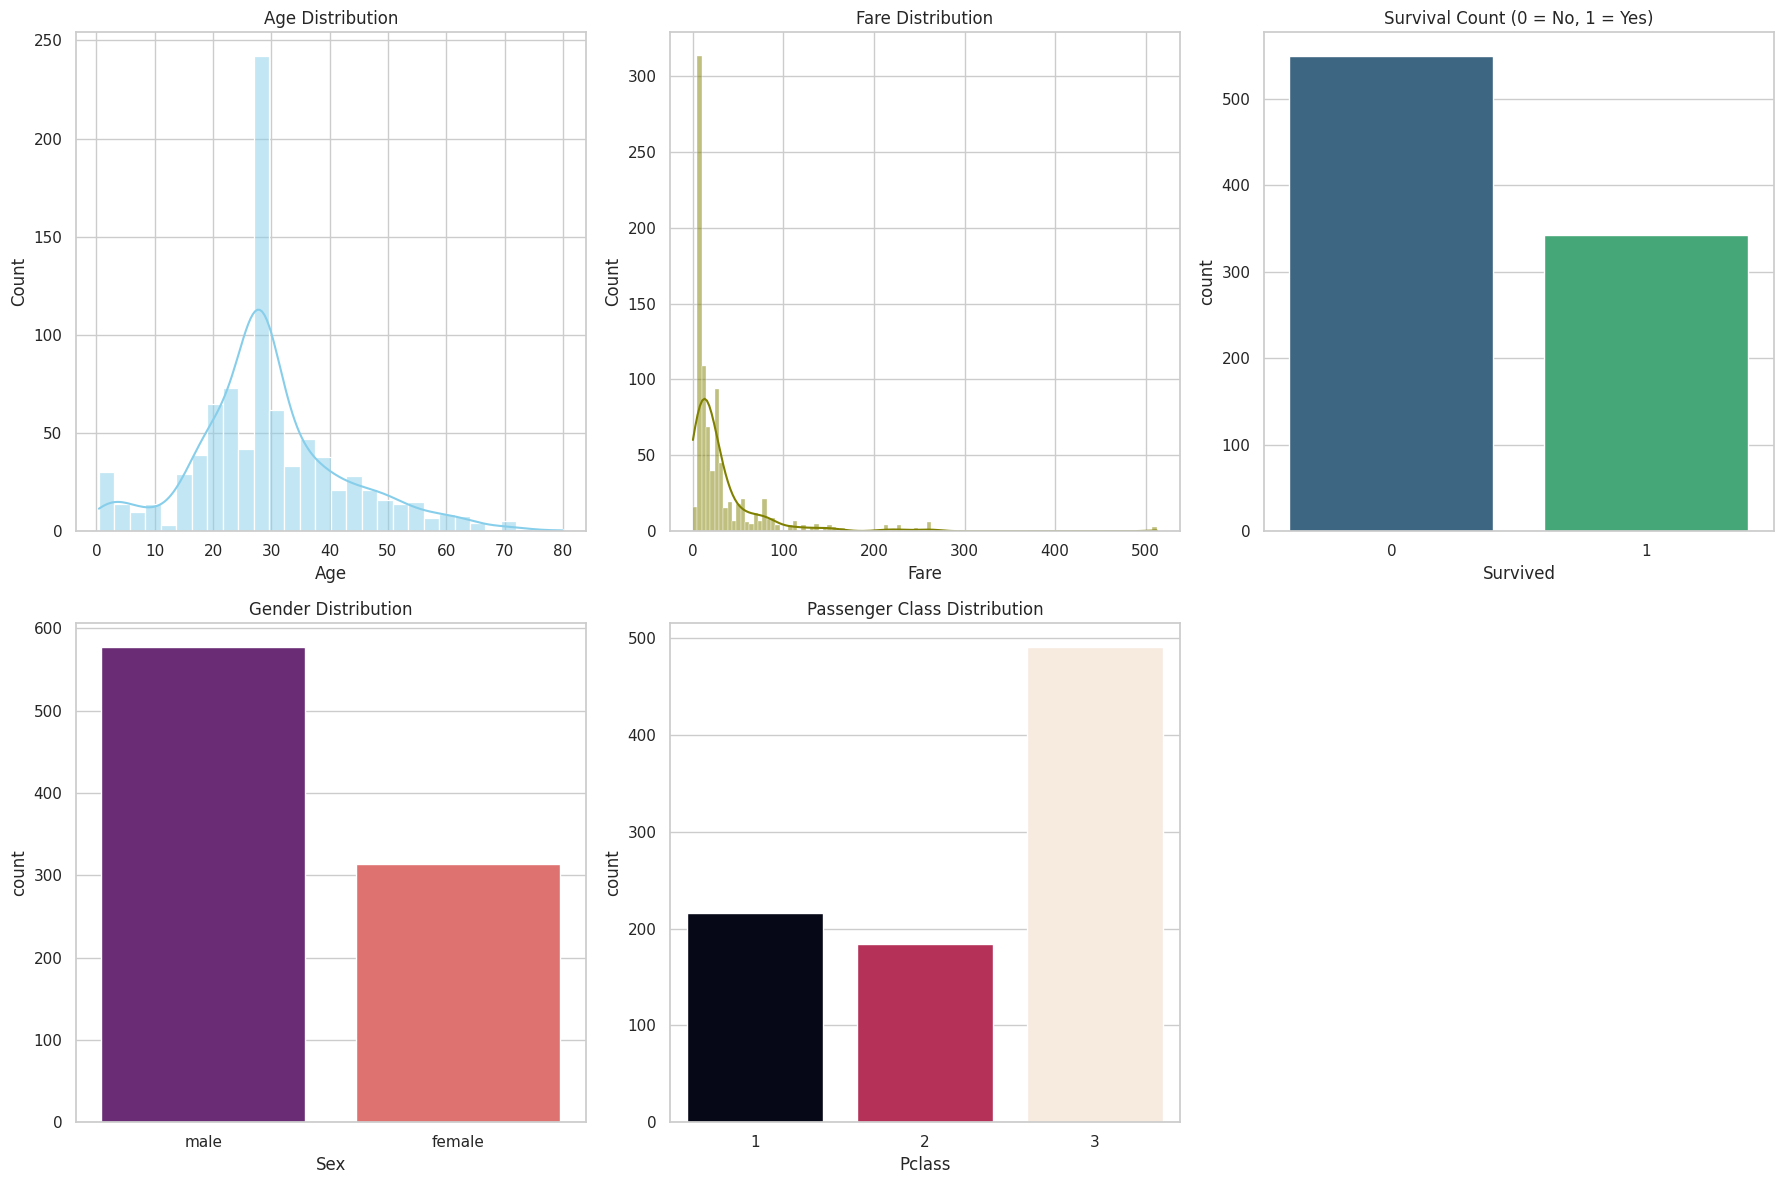

In [12]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

sns.histplot(df['Age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age Distribution')

sns.histplot(df['Fare'], kde=True, ax=axes[0, 1], color='olive')
axes[0, 1].set_title('Fare Distribution')

sns.countplot(x='Survived', hue='Survived', data=df, ax=axes[0, 2], palette='viridis', legend=False)
axes[0, 2].set_title('Survival Count (0 = No, 1 = Yes)')

sns.countplot(x='Sex', hue='Sex', data=df, ax=axes[1, 0], palette='magma', legend=False)
axes[1, 0].set_title('Gender Distribution')

sns.countplot(x='Pclass', hue='Pclass', data=df, ax=axes[1, 1], palette='rocket', legend=False)
axes[1, 1].set_title('Passenger Class Distribution')

fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

The Fare histogram show that there are some really big prices that will disturb in linear models. we need to handle the issue. We use log() for that to make big numbers less big and small numbers almost unchanged.

In [13]:
np.log(df['Fare']+1)

,Fare
0,2.110213
1,4.280593
2,2.188856
3,3.990834
4,2.202765
...,...
886,2.639057
887,3.433987
888,3.196630
889,3.433987


In [14]:
df["LogFare"] = np.log(df['Fare']+1)
df["LogFare"]

,LogFare
0,2.110213
1,4.280593
2,2.188856
3,3.990834
4,2.202765
...,...
886,2.639057
887,3.433987
888,3.196630
889,3.433987


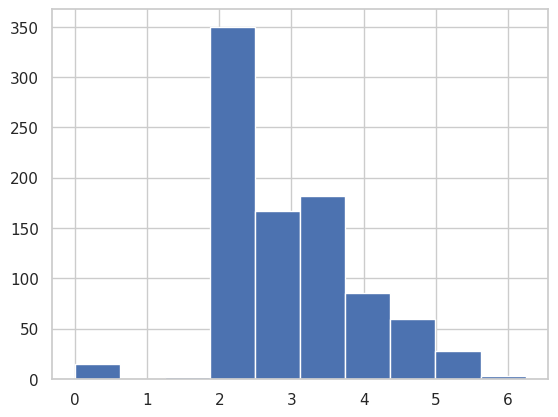

In [15]:
df["LogFare"].hist();

In [16]:
df.Pclass.unique()

array([3, 1, 2])

In [17]:
pclasses = sorted(df.Pclass.unique())
pclasses

[np.int64(1), np.int64(2), np.int64(3)]

non numeric columns now

In [18]:
df.describe(include=[object])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,891
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,B96 B98,S
freq,1,577,7,691,646


Because ML models understand only number and in the dataset names, sexex, Cabins cant be multiply by coefficient we need to replace them with numbers

In [19]:
cols_to_encode = ['Pclass', 'Sex', 'Embarked']
existing_cols = [c for c in cols_to_encode if c in df.columns]
if existing_cols:
    df = pd.get_dummies(df, columns=existing_cols)

print(df.columns)

Index(['PassengerId', 'Survived', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'LogFare', 'Pclass_1', 'Pclass_2',
       'Pclass_3', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [20]:
t_dep = torch.tensor(df.Survived)

indep_cols = ['Age', 'SibSp', 'Parch', 'LogFare', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
t_indep = torch.tensor(df[indep_cols].astype(float).values, dtype=torch.float)

t_indep

tensor([[22.0000,  1.0000,  0.0000,  2.1102,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [38.0000,  1.0000,  0.0000,  4.2806,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000],
        [26.0000,  0.0000,  0.0000,  2.1889,  0.0000,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000],
        [35.0000,  1.0000,  0.0000,  3.9908,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000],
        [35.0000,  0.0000,  0.0000,  2.2028,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [28.0000,  0.0000,  0.0000,  2.2469,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000],
        [54.0000,  0.0000,  0.0000,  3.9677,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        ...,
        [25.0000,  0.0000,  0.0000,  2.0857,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [39.0000,  0.0000,  5.0000,  3.4054

In [21]:
t_indep.shape

torch.Size([891, 12])

In [22]:
t_dep

tensor([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
        1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
        0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
        1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
        0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
        0, 1, 1, 1, 

LINEAR MODEL

In [23]:
torch.manual_seed(442)

n_coeff = t_indep.shape[1]
coeffs = torch.rand(n_coeff) - 0.5
coeffs.requires_grad_()

bias = torch.rand(1) - 0.5
bias.requires_grad_()

print(f"Coefficients: {coeffs}")
print(f"Bias: {bias}")

Coefficients: tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,  0.2799, -0.4392,  0.2103,  0.3625], requires_grad=True)
Bias: tensor([0.1722], requires_grad=True)


Multiply a matrix and a vector using broadcasting(from APL). It takes each coeff and multiply by each row in the matrix.

In [24]:
t_indep.max(dim=0)

torch.return_types.max(
values=tensor([80.0000,  8.0000,  6.0000,  6.2409,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000]),
indices=tensor([630, 159, 678, 258,   1,   9,   0,   1,   0,   1,   5,   0]))

In [25]:
vals, _ = t_indep.max(dim=0) # dim=0 - we take maximum of the rows
t_indep = t_indep / vals
t_indep

tensor([[0.2750, 0.1250, 0.0000, 0.3381, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.4750, 0.1250, 0.0000, 0.6859, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000],
        [0.3250, 0.0000, 0.0000, 0.3507, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.4375, 0.1250, 0.0000, 0.6395, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.4375, 0.0000, 0.0000, 0.3530, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.3500, 0.0000, 0.0000, 0.3600, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000],
        [0.6750, 0.0000, 0.0000, 0.6358, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        ...,
        [0.3125, 0.0000, 0.0000, 0.3342, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.4875, 0.0000, 0.8333, 0.5456, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000],
        [0.3375, 0.0000, 0.0000, 

In [26]:
preds = (t_indep * coeffs).sum(axis=1) + bias
preds[:10]

tensor([ 1.1157, -0.5743,  1.1061,  0.2552,  1.0198,  0.9065,  0.0951,  1.2706,  1.1695, -0.4563], grad_fn=<SliceBackward0>)

A linear model is defined as `y = x ∘ w + b` (where ∘ is the dot product). We can calculate the predictions for all rows in one go using matrix multiplication or element-wise multiplication followed by a sum.

We need to use gradient deescent tp make prediction better and to use GD we need the loss(meseares how good or bad is the predictin)

In [27]:
loss = torch.abs(preds - t_dep).mean()
loss

tensor(0.7427, grad_fn=<MeanBackward0>)

In [28]:
loss.backward()
print(f"Coefficients Gradient: {coeffs.grad}")
print(f"Bias Gradient: {bias.grad}")

Coefficients Gradient: tensor([ 0.0941,  0.0261,  0.0116,  0.0669, -0.1212, -0.0090,  0.4231, -0.0943,  0.3872, -0.0965,  0.0236,  0.3659])
Bias Gradient: tensor([0.2929])


In [29]:
preds = (t_indep * coeffs).sum(axis=1) + bias
preds[:10]

tensor([ 1.1157, -0.5743,  1.1061,  0.2552,  1.0198,  0.9065,  0.0951,  1.2706,  1.1695, -0.4563], grad_fn=<SliceBackward0>)

In [30]:
def calc_preds(coeffs, bias, indeps):
    return (indeps * coeffs).sum(axis=1) + bias

def calc_loss(coeffs, bias, indeps, deps):
    preds = calc_preds(coeffs, bias, indeps)
    return torch.abs(preds - deps).mean()

In [31]:
# 1. Calculate loss
loss = calc_loss(coeffs, bias, t_indep, t_dep)

# 2. Compute gradients
loss.backward()

# 3. Update parameters
with torch.no_grad():
    learning_rate = 0.1
    coeffs -= coeffs.grad * learning_rate
    bias -= bias.grad * learning_rate

    # 4. Zero the gradients for the next step
    coeffs.grad.zero_()
    bias.grad.zero_()

print(f"Loss after one step: {loss.item()}")

Loss after one step: 0.7426774501800537


# Training the linear model


In [32]:
n = t_indep.shape[0]
split_point = int(n * 0.8)

torch.manual_seed(42)
idxs = torch.randperm(n)

train_idx = idxs[:split_point]
val_idx = idxs[split_point:]

train_indep, train_dep = t_indep[train_idx], t_dep[train_idx]
val_indep, val_dep = t_indep[val_idx], t_dep[val_idx]

print(f'Training set shape: {train_indep.shape}, {train_dep.shape}')
print(f'Validation set shape: {val_indep.shape}, {val_dep.shape}')

Training set shape: torch.Size([712, 12]), torch.Size([712])
Validation set shape: torch.Size([179, 12]), torch.Size([179])


In [33]:
torch.manual_seed(442)

n_coeff = train_indep.shape[1]
coeffs = (torch.rand(n_coeff) - 0.5).requires_grad_()
bias = (torch.rand(1) - 0.5).requires_grad_()

print(f'Initialized Coefficients:\n{coeffs}')
print(f'Initialized Bias: {bias}')

Initialized Coefficients:
tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,  0.2799, -0.4392,  0.2103,  0.3625], requires_grad=True)
Initialized Bias: tensor([0.1722], requires_grad=True)


In [34]:
epochs = 30
learning_rate = 0.1
train_losses = []
val_losses = []

for i in range(epochs):
    # 1. Calculate training loss
    loss = calc_loss(coeffs, bias, train_indep, train_dep)

    # 2. Compute gradients
    loss.backward()

    # 3. Update parameters
    with torch.no_grad():
        coeffs -= coeffs.grad * learning_rate
        bias -= bias.grad * learning_rate

        # 4. Zero the gradients
        coeffs.grad.zero_()
        bias.grad.zero_()

        # 5. Calculate validation loss (no grad needed for validation)
        v_loss = calc_loss(coeffs, bias, val_indep, val_dep)

    # Store losses
    train_losses.append(loss.item())
    val_losses.append(v_loss.item())

    if (i+1) % 5 == 0:
        print(f'Epoch {i+1}: Train Loss: {loss.item():.4f}, Val Loss: {v_loss.item():.4f}')

print('\nFinal Training Loss:', train_losses[-1])
print('Final Validation Loss:', val_losses[-1])

Epoch 5: Train Loss: 0.6259, Val Loss: 0.5391
Epoch 10: Train Loss: 0.5314, Val Loss: 0.4537
Epoch 15: Train Loss: 0.4411, Val Loss: 0.3708
Epoch 20: Train Loss: 0.3533, Val Loss: 0.2912
Epoch 25: Train Loss: 0.2814, Val Loss: 0.2345
Epoch 30: Train Loss: 0.2640, Val Loss: 0.2425

Final Training Loss: 0.2640182673931122
Final Validation Loss: 0.24249771237373352


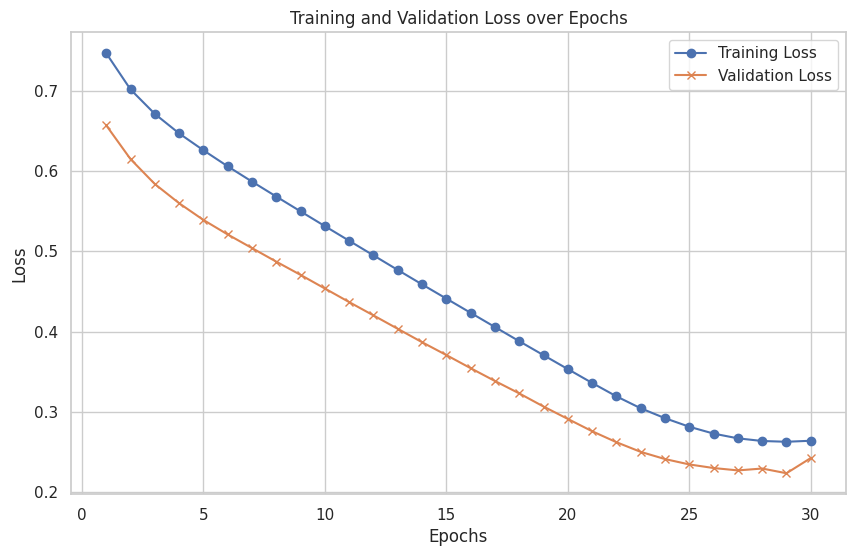

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', marker='x')

plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Accuracy

In [36]:
def calc_accuracy(coeffs, bias, indeps, deps):
    preds = calc_preds(coeffs, bias, indeps)
    return ((preds > 0.5).float() == deps).float().mean()

acc = calc_accuracy(coeffs, bias, val_indep, val_dep)
print(f'Validation Accuracy: {acc.item():.4f}')

Validation Accuracy: 0.8268


In [41]:
torch.manual_seed(442)

n_coeff = train_indep.shape[1]
coeffs = (torch.rand(n_coeff) - 0.5).requires_grad_()
bias = (torch.rand(1) - 0.5).requires_grad_()

epochs = 30
learning_rate = 0.1
train_losses = []
val_losses = []
val_accuracies = []

for i in range(epochs):
    # 1. Calculate training loss
    loss = calc_loss(coeffs, bias, train_indep, train_dep)

    # 2. Compute gradients
    loss.backward()

    # 3. Update parameters
    with torch.no_grad():
        coeffs -= coeffs.grad * learning_rate
        bias -= bias.grad * learning_rate

        # 4. Zero the gradients
        coeffs.grad.zero_()
        bias.grad.zero_()

        # 5. Calculate validation loss and accuracy
        v_loss = calc_loss(coeffs, bias, val_indep, val_dep)
        v_acc = calc_accuracy(coeffs, bias, val_indep, val_dep)

    # Store metrics
    train_losses.append(loss.item())
    val_losses.append(v_loss.item())
    val_accuracies.append(v_acc.item())

    if (i+1) % 5 == 0:
        print(f'Epoch {i+1}: Train Loss: {loss.item():.4f}, Val Loss: {v_loss.item():.4f}, Val Acc: {v_acc.item():.4f}')

print('\nFinal Training Loss:', train_losses[-1])
print('Final Validation Loss:', val_losses[-1])
print('Final Validation Accuracy:', val_accuracies[-1])

Epoch 5: Train Loss: 0.6259, Val Loss: 0.5391, Val Acc: 0.4022
Epoch 10: Train Loss: 0.5314, Val Loss: 0.4537, Val Acc: 0.5698
Epoch 15: Train Loss: 0.4411, Val Loss: 0.3708, Val Acc: 0.7542
Epoch 20: Train Loss: 0.3533, Val Loss: 0.2912, Val Acc: 0.8212
Epoch 25: Train Loss: 0.2814, Val Loss: 0.2345, Val Acc: 0.8268
Epoch 30: Train Loss: 0.2640, Val Loss: 0.2425, Val Acc: 0.8268

Final Training Loss: 0.2640182673931122
Final Validation Loss: 0.24249771237373352
Final Validation Accuracy: 0.826815664768219


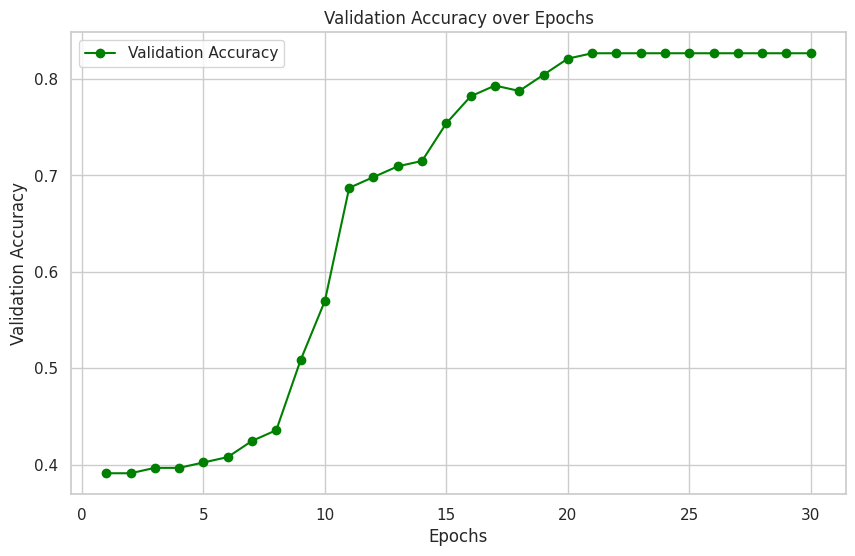

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', marker='o', color='green')

plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()